# VR Distraction Experiment Analysis

This notebook processes the Unity event logs for participants P01–P08. It keeps only the final complete experiment block for P01, creates one row per participant × condition, computes behavioral and questionnaire metrics, checks learning effects, runs repeated-measures ANOVA, and saves plots/tables for the report.



## Imports, paths, and condition setup

In [1]:
"""
VR Attention & Distraction Lab - Behavioral data analysis
Processes Unity event_log_P01.csv to event_log_P08.csv files into participant-condition summaries,
creates descriptive statistics, learning-effect checks, plots, and repeated-measures ANOVA tables.
"""
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.anova import AnovaRM


DATA_DIR = Path("/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs")
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

EXPECTED_CONDITIONS = [
    "C1_VisualOff_AudioOff",
    "C2_VisualPredictable_AudioOff",
    "C3_VisualUnpredictable_AudioOff",
    "C4_VisualOff_AudioPredictable",
    "C5_VisualPredictable_AudioPredictable",
    "C6_VisualUnpredictable_AudioPredictable",
    "C7_VisualOff_AudioUnpredictable",
    "C8_VisualPredictable_AudioUnpredictable",
    "C9_VisualUnpredictable_AudioUnpredictable",
]

QUESTION_LABELS = {
    "Q1": "MentalDemand",
    "Q2": "PhysicalDemand",
    "Q3": "TemporalDemand",
    "Q4": "PerformanceSatisfaction",
    "Q5": "Effort",
    "Q6": "Frustration",
}

## Robust log reader and cleaning functions

In [3]:
def read_event_log(path: Path) -> pd.DataFrame:
    """Read logs where questionnaire text contains unescaped commas.

    The log nominally has 7 columns:
    timestamp,event_type,round_index,condition_id,object_id,extra_1,extra_2

    However, questionnaire rows contain commas in extra_1, so normal pd.read_csv fails.
    This parser keeps the first five comma-separated fields, the final field as extra_2,
    and joins everything in between as extra_1.
    """
    rows = []
    with open(path, encoding="utf-8-sig") as f:
        first = f.readline().strip()
        lines = []
        if first and not first.startswith("timestamp,event_type"):
            lines.append(first)
        lines.extend(line.rstrip("\n") for line in f if line.strip())

    for line in lines:
        parts = line.split(",")
        if len(parts) < 7:
            continue
        rows.append({
            "timestamp": parts[0],
            "event_type": parts[1],
            "round_index": parts[2],
            "condition_id": parts[3],
            "object_id": parts[4],
            "extra_1": ",".join(parts[5:-1]),
            "extra_2": parts[-1],
        })

    df = pd.DataFrame(rows)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["round_index"] = pd.to_numeric(df["round_index"], errors="coerce").astype("Int64")
    return df


def keep_final_complete_experiment(df: pd.DataFrame, participant: str) -> pd.DataFrame:
    """Keep the last complete 9-round experiment block.

    This is especially important for P01, where earlier rows are pilot/testing logs.
    P02 and P03 also contain an initial duplicate EXPERIMENT_START, so the same rule
    safely keeps the complete participant block.
    """
    start_indices = df.index[df["event_type"].eq("EXPERIMENT_START")].tolist()
    if not start_indices:
        return df.copy()

    boundaries = start_indices + [len(df)]
    for i in range(len(start_indices) - 1, -1, -1):
        start = boundaries[i]
        end = boundaries[i + 1]
        segment = df.iloc[start:end].copy()
        round_ends = segment[segment["event_type"].eq("ROUND_END")]
        conditions = set(round_ends["condition_id"].dropna().tolist())
        rounds = set(round_ends["round_index"].dropna().astype(int).tolist())
        if len(round_ends) >= 9 and set(EXPECTED_CONDITIONS).issubset(conditions) and set(range(1, 10)).issubset(rounds):
            return segment.reset_index(drop=True)

    round_end_idx = df.index[df["event_type"].eq("ROUND_END")].tolist()
    if len(round_end_idx) >= 9:
        first_needed = round_end_idx[-9]
        previous_starts = [idx for idx in start_indices if idx <= first_needed]
        start = previous_starts[-1] if previous_starts else first_needed
        return df.loc[start:].reset_index(drop=True)

    warnings.warn(f"{participant}: no complete 9-round experiment found; using whole file.")
    return df.copy().reset_index(drop=True)


def parse_condition(condition_id: str) -> pd.Series:
    """Split condition ID into audio and visual levels."""
    match = re.match(r"C(\d+)_Visual(Off|Predictable|Unpredictable)_Audio(Off|Predictable|Unpredictable)", str(condition_id))
    if not match:
        return pd.Series({"ConditionNumber": np.nan, "Visual": np.nan, "Audio": np.nan})
    return pd.Series({
        "ConditionNumber": int(match.group(1)),
        "Visual": match.group(2),
        "Audio": match.group(3),
    })


def summarize_rounds(df: pd.DataFrame, participant: str) -> pd.DataFrame:
    """Create one summary row per participant x round/condition."""
    rows = []
    round_ends = df[df["event_type"].eq("ROUND_END")].copy()

    for _, end_row in round_ends.iterrows():
        r = int(end_row["round_index"])
        cond = end_row["condition_id"]
        round_df = df[(df["round_index"].eq(r)) & (df["condition_id"].eq(cond))].copy()

        start_rows = round_df[round_df["event_type"].eq("ROUND_START")]
        end_rows = round_df[round_df["event_type"].eq("ROUND_END")]
        start_time = start_rows["timestamp"].iloc[0] if not start_rows.empty else pd.NaT
        end_time = end_rows["timestamp"].iloc[-1] if not end_rows.empty else pd.NaT

        logged_time = pd.to_numeric(pd.Series([end_row["extra_1"]]), errors="coerce").iloc[0]
        computed_time = (end_time - start_time).total_seconds() if pd.notna(start_time) and pd.notna(end_time) else np.nan
        completion_time = logged_time if pd.notna(logged_time) else computed_time

        thinking = pd.to_numeric(round_df.loc[round_df["event_type"].eq("THINKING_TIME"), "extra_1"], errors="coerce")

        q = round_df[round_df["event_type"].eq("QUESTIONNAIRE_ANSWER")].copy()
        q["answer"] = pd.to_numeric(q["extra_2"], errors="coerce")
        q_values = {QUESTION_LABELS.get(k, k): v for k, v in q.groupby("object_id")["answer"].last().items()}

        row = {
            "Participant": participant,
            "Round": r,
            "Condition": cond,
            "CompletionTime_s": completion_time,
            "CompletionTime_from_timestamps_s": computed_time,
            "Matches": int(round_df["event_type"].eq("MATCH").sum()),
            "Mismatches": int(round_df["event_type"].eq("MISMATCH").sum()),
            "Rechecks": int(round_df["event_type"].eq("RECHECK").sum()),
            "CardFlips": int(round_df["event_type"].eq("CARD_FLIP").sum()),
            "AvgThinkingTime_s": thinking.mean(),
            "MedianThinkingTime_s": thinking.median(),
            "MaxThinkingTime_s": thinking.max(),
            "DistractorOnEvents": int(round_df["event_type"].eq("DISTRACTOR_ON").sum()),
            "DistractorOffEvents": int(round_df["event_type"].eq("DISTRACTOR_OFF").sum()),
        }
        row.update(q_values)
        rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    condition_parts = out["Condition"].apply(parse_condition)
    out = pd.concat([out, condition_parts], axis=1)

    workload_cols = ["MentalDemand", "PhysicalDemand", "TemporalDemand", "Effort", "Frustration"]
    for c in workload_cols + ["PerformanceSatisfaction"]:
        if c not in out.columns:
            out[c] = np.nan
    out["Workload_mean_without_Q4"] = out[workload_cols].mean(axis=1)
    out["NASA_TLX_simple_mean_all_Qs"] = out[[*workload_cols, "PerformanceSatisfaction"]].mean(axis=1)

    return out.sort_values("Round").reset_index(drop=True)

## Process all participant logs and save master dataset

In [4]:
csv_files = sorted(DATA_DIR.rglob("event_log_P*.csv"))

print("CSV files found:", len(csv_files))
for f in csv_files:
    print(f)

all_summaries = []
quality_rows = []

for path in csv_files:
    participant_match = re.search(r"P\d+", path.name)
    if not participant_match:
        print("Skipping file, no participant ID:", path.name)
        continue

    participant = participant_match.group(0).upper()

    raw = read_event_log(path)
    clean = keep_final_complete_experiment(raw, participant)
    summary = summarize_rounds(clean, participant)

    if summary.empty:
        print("Skipping empty summary:", participant)
        continue

    all_summaries.append(summary)

    quality_rows.append({
        "Participant": participant,
        "RawRows": len(raw),
        "CleanRowsUsed": len(clean),
        "RawExperimentStarts": int(raw["event_type"].eq("EXPERIMENT_START").sum()),
        "RoundsUsed": int(summary.shape[0]),
        "All9ConditionsPresent": set(EXPECTED_CONDITIONS).issubset(set(summary["Condition"].dropna())),
        "FirstTimestampUsed": clean["timestamp"].min(),
        "LastTimestampUsed": clean["timestamp"].max(),
    })

if not all_summaries:
    raise ValueError("No participant summaries created. Check DATA_DIR and CSV file names.")
master = pd.concat(all_summaries, ignore_index=True)

quality = pd.DataFrame(quality_rows).sort_values("Participant")

master.to_csv(OUTPUT_DIR / "master_participant_condition_summary.csv", index=False)
quality.to_csv(OUTPUT_DIR / "data_quality_check.csv", index=False)

CSV files found: 8
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P01.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P02.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P03.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P04.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P05.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P06.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P07.csv
/Users/berinvenedik/Desktop/Uni/Semester 6/BSP 6/event logs/event_log_P08.csv


## Descriptive statistics and learning-effect checks

In [4]:
metric_cols = [
    "CompletionTime_s", "Mismatches", "Rechecks", "CardFlips", "AvgThinkingTime_s",
    "MentalDemand", "PhysicalDemand", "TemporalDemand", "PerformanceSatisfaction",
    "Effort", "Frustration", "Workload_mean_without_Q4"
]

condition_stats = (
    master.groupby(["Condition", "Visual", "Audio"], observed=True)[metric_cols]
    .agg(["mean", "std", "median", "min", "max"])
    .reset_index()
)
condition_stats.to_csv(OUTPUT_DIR / "condition_descriptive_statistics.csv", index=False)

report_means = (
    master.groupby(["Condition", "Visual", "Audio"], observed=True)
    .agg(
        N=("Participant", "nunique"),
        MeanTime_s=("CompletionTime_s", "mean"),
        SDTime_s=("CompletionTime_s", "std"),
        MeanMismatches=("Mismatches", "mean"),
        SDMismatches=("Mismatches", "std"),
        MeanFlips=("CardFlips", "mean"),
        SDFlips=("CardFlips", "std"),
        MeanWorkload=("Workload_mean_without_Q4", "mean"),
        SDWorkload=("Workload_mean_without_Q4", "std"),
    )
    .reset_index()
)
report_means.to_csv(OUTPUT_DIR / "report_condition_means.csv", index=False)

round_stats = (
    master.groupby("Round")[["CompletionTime_s", "Mismatches", "CardFlips", "Workload_mean_without_Q4"]]
    .agg(["mean", "std", "median"])
    .reset_index()
)
round_stats.to_csv(OUTPUT_DIR / "round_order_learning_effect_stats.csv", index=False)

correlation_rows = []
for metric in ["CompletionTime_s", "Mismatches", "Rechecks", "CardFlips", "AvgThinkingTime_s", "Workload_mean_without_Q4"]:
    tmp = master[["Round", metric]].dropna()
    r, p = stats.pearsonr(tmp["Round"], tmp[metric]) if len(tmp) > 2 else (np.nan, np.nan)
    correlation_rows.append({"Predictor": "Round", "Metric": metric, "Pearson_r": r, "p_value": p})
correlations = pd.DataFrame(correlation_rows)
correlations.to_csv(OUTPUT_DIR / "round_order_correlations.csv", index=False)

## Repeated-measures ANOVA

In [5]:
def run_anova(metric: str) -> pd.DataFrame:
    data = master[["Participant", "Visual", "Audio", metric]].dropna().copy()
    # Ensure one row per participant x visual x audio.
    data = data.groupby(["Participant", "Visual", "Audio"], observed=True)[metric].mean().reset_index()
    try:
        result = AnovaRM(data, depvar=metric, subject="Participant", within=["Visual", "Audio"]).fit()
        table = result.anova_table.reset_index().rename(columns={"index": "Effect"})
        table.insert(0, "Metric", metric)
        return table
    except Exception as e:
        return pd.DataFrame([{"Metric": metric, "Effect": "ERROR", "Error": str(e)}])

anova_metrics = ["CompletionTime_s", "Mismatches", "Rechecks", "CardFlips", "AvgThinkingTime_s", "Workload_mean_without_Q4"]
anova_results = pd.concat([run_anova(m) for m in anova_metrics], ignore_index=True)
anova_results.to_csv(OUTPUT_DIR / "repeated_measures_anova_results.csv", index=False)

## Generate plots

In [6]:
sns.set_theme(style="whitegrid")

for metric, ylabel, filename in [
    ("CompletionTime_s", "Completion time (seconds)", "boxplot_completion_time_by_condition.png"),
    ("Mismatches", "Mismatches", "boxplot_mismatches_by_condition.png"),
    ("CardFlips", "Card flips", "boxplot_card_flips_by_condition.png"),
    ("Workload_mean_without_Q4", "Workload mean (Q1,Q2,Q3,Q5,Q6)", "boxplot_workload_by_condition.png"),
]:
    plt.figure(figsize=(13, 6))
    sns.boxplot(data=master, x="Condition", y=metric)
    sns.stripplot(data=master, x="Condition", y=metric, color="black", alpha=0.5, size=4)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.xlabel("Condition")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.close()

for metric, ylabel, filename in [
    ("CompletionTime_s", "Mean completion time (seconds)", "interaction_completion_time.png"),
    ("Mismatches", "Mean mismatches", "interaction_mismatches.png"),
    ("CardFlips", "Mean card flips", "interaction_card_flips.png"),
    ("Workload_mean_without_Q4", "Mean workload", "interaction_workload.png"),
]:
    plt.figure(figsize=(8, 5))
    sns.pointplot(data=master, x="Visual", y=metric, hue="Audio", errorbar="se", dodge=True, markers="o")
    plt.ylabel(ylabel)
    plt.xlabel("Visual distraction")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.close()

for metric, ylabel, filename in [
    ("CompletionTime_s", "Completion time (seconds)", "learning_effect_completion_time_by_round.png"),
    ("Mismatches", "Mismatches", "learning_effect_mismatches_by_round.png"),
    ("CardFlips", "Card flips", "learning_effect_card_flips_by_round.png"),
]:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=master, x="Round", y=metric, x_estimator=np.mean, scatter=True)
    plt.ylabel(ylabel)
    plt.xlabel("Round order")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.close()

plt.figure(figsize=(9, 5))
sns.lineplot(data=master, x="Round", y="CompletionTime_s", hue="Participant", marker="o")
plt.ylabel("Completion time (seconds)")
plt.xlabel("Round order")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "participant_trajectories_completion_time.png", dpi=200)
plt.close()

## Quick summary tables

In [7]:
print('Data quality check')
display(quality)

print('Main report means')
display(report_means[['Condition','N','MeanTime_s','MeanMismatches','MeanFlips','MeanWorkload']])

print('Repeated-measures ANOVA')
display(anova_results)

print('Round-order correlations')
display(correlations)

Data quality check


,Participant,RawRows,CleanRowsUsed,RawExperimentStarts,RoundsUsed,All9ConditionsPresent,FirstTimestampUsed,LastTimestampUsed
0,P01,4807,1013,20,9,True,2026-05-27 11:43:12.107,2026-05-27 11:59:29.574
1,P02,1235,1230,2,9,True,2026-05-27 12:16:44.368,2026-05-27 12:30:43.875
2,P03,990,985,2,9,True,2026-05-27 12:46:15.028,2026-05-27 12:59:15.782
3,P04,1458,1458,1,9,True,2026-05-28 13:13:51.369,2026-05-28 13:33:04.401
4,P05,1269,1269,1,9,True,2026-05-28 13:43:16.662,2026-05-28 13:57:48.193
5,P06,1084,1084,1,9,True,2026-05-28 14:14:31.936,2026-05-28 14:30:54.287
6,P07,1157,1157,1,9,True,2026-05-28 14:53:34.202,2026-05-28 15:12:15.849
7,P08,863,863,1,9,True,2026-05-28 15:18:54.873,2026-05-28 15:31:07.733


Main report means


,Condition,N,MeanTime_s,MeanMismatches,MeanFlips,MeanWorkload
0,C1_VisualOff_AudioOff,8,55.46750,9.250,34.50,28.750
1,C2_VisualPredictable_AudioOff,8,54.32625,10.250,36.50,33.150
2,C3_VisualUnpredictable_AudioOff,8,48.49375,10.375,36.75,37.350
3,C4_VisualOff_AudioPredictable,8,46.43625,11.250,38.50,44.725
4,C5_VisualPredictable_AudioPredictable,8,42.24875,9.625,35.25,43.875
5,C6_VisualUnpredictable_AudioPredictable,8,46.81500,11.125,38.25,49.850
6,C7_VisualOff_AudioUnpredictable,8,41.59625,10.000,36.00,46.575
7,C8_VisualPredictable_AudioUnpredictable,8,39.60625,8.250,32.50,49.650
8,C9_VisualUnpredictable_AudioUnpredictable,8,42.25375,10.125,36.25,52.575


Repeated-measures ANOVA


,Metric,Effect,F Value,Num DF,Den DF,Pr > F
0,CompletionTime_s,Visual,0.969285,2.0,14.0,4.034140e-01
1,CompletionTime_s,Audio,5.348401,2.0,14.0,1.881097e-02
2,CompletionTime_s,Visual:Audio,0.893379,4.0,28.0,4.809201e-01
3,Mismatches,Visual,1.406424,2.0,14.0,2.775922e-01
4,Mismatches,Audio,0.640385,2.0,14.0,5.418507e-01
5,Mismatches,Visual:Audio,0.759242,4.0,28.0,5.605732e-01
6,Rechecks,Visual,1.406424,2.0,14.0,2.775922e-01
7,Rechecks,Audio,0.640385,2.0,14.0,5.418507e-01
8,Rechecks,Visual:Audio,0.759242,4.0,28.0,5.605732e-01
9,CardFlips,Visual,1.406424,2.0,14.0,2.775922e-01


Round-order correlations


,Predictor,Metric,Pearson_r,p_value
0,Round,CompletionTime_s,-0.430943,0.000158
1,Round,Mismatches,-0.037294,0.755783
2,Round,Rechecks,-0.037294,0.755783
3,Round,CardFlips,-0.037294,0.755783
4,Round,AvgThinkingTime_s,-0.065281,0.585879
5,Round,Workload_mean_without_Q4,0.464576,0.000039


## View saved plots inside notebook

boxplot_completion_time_by_condition.png


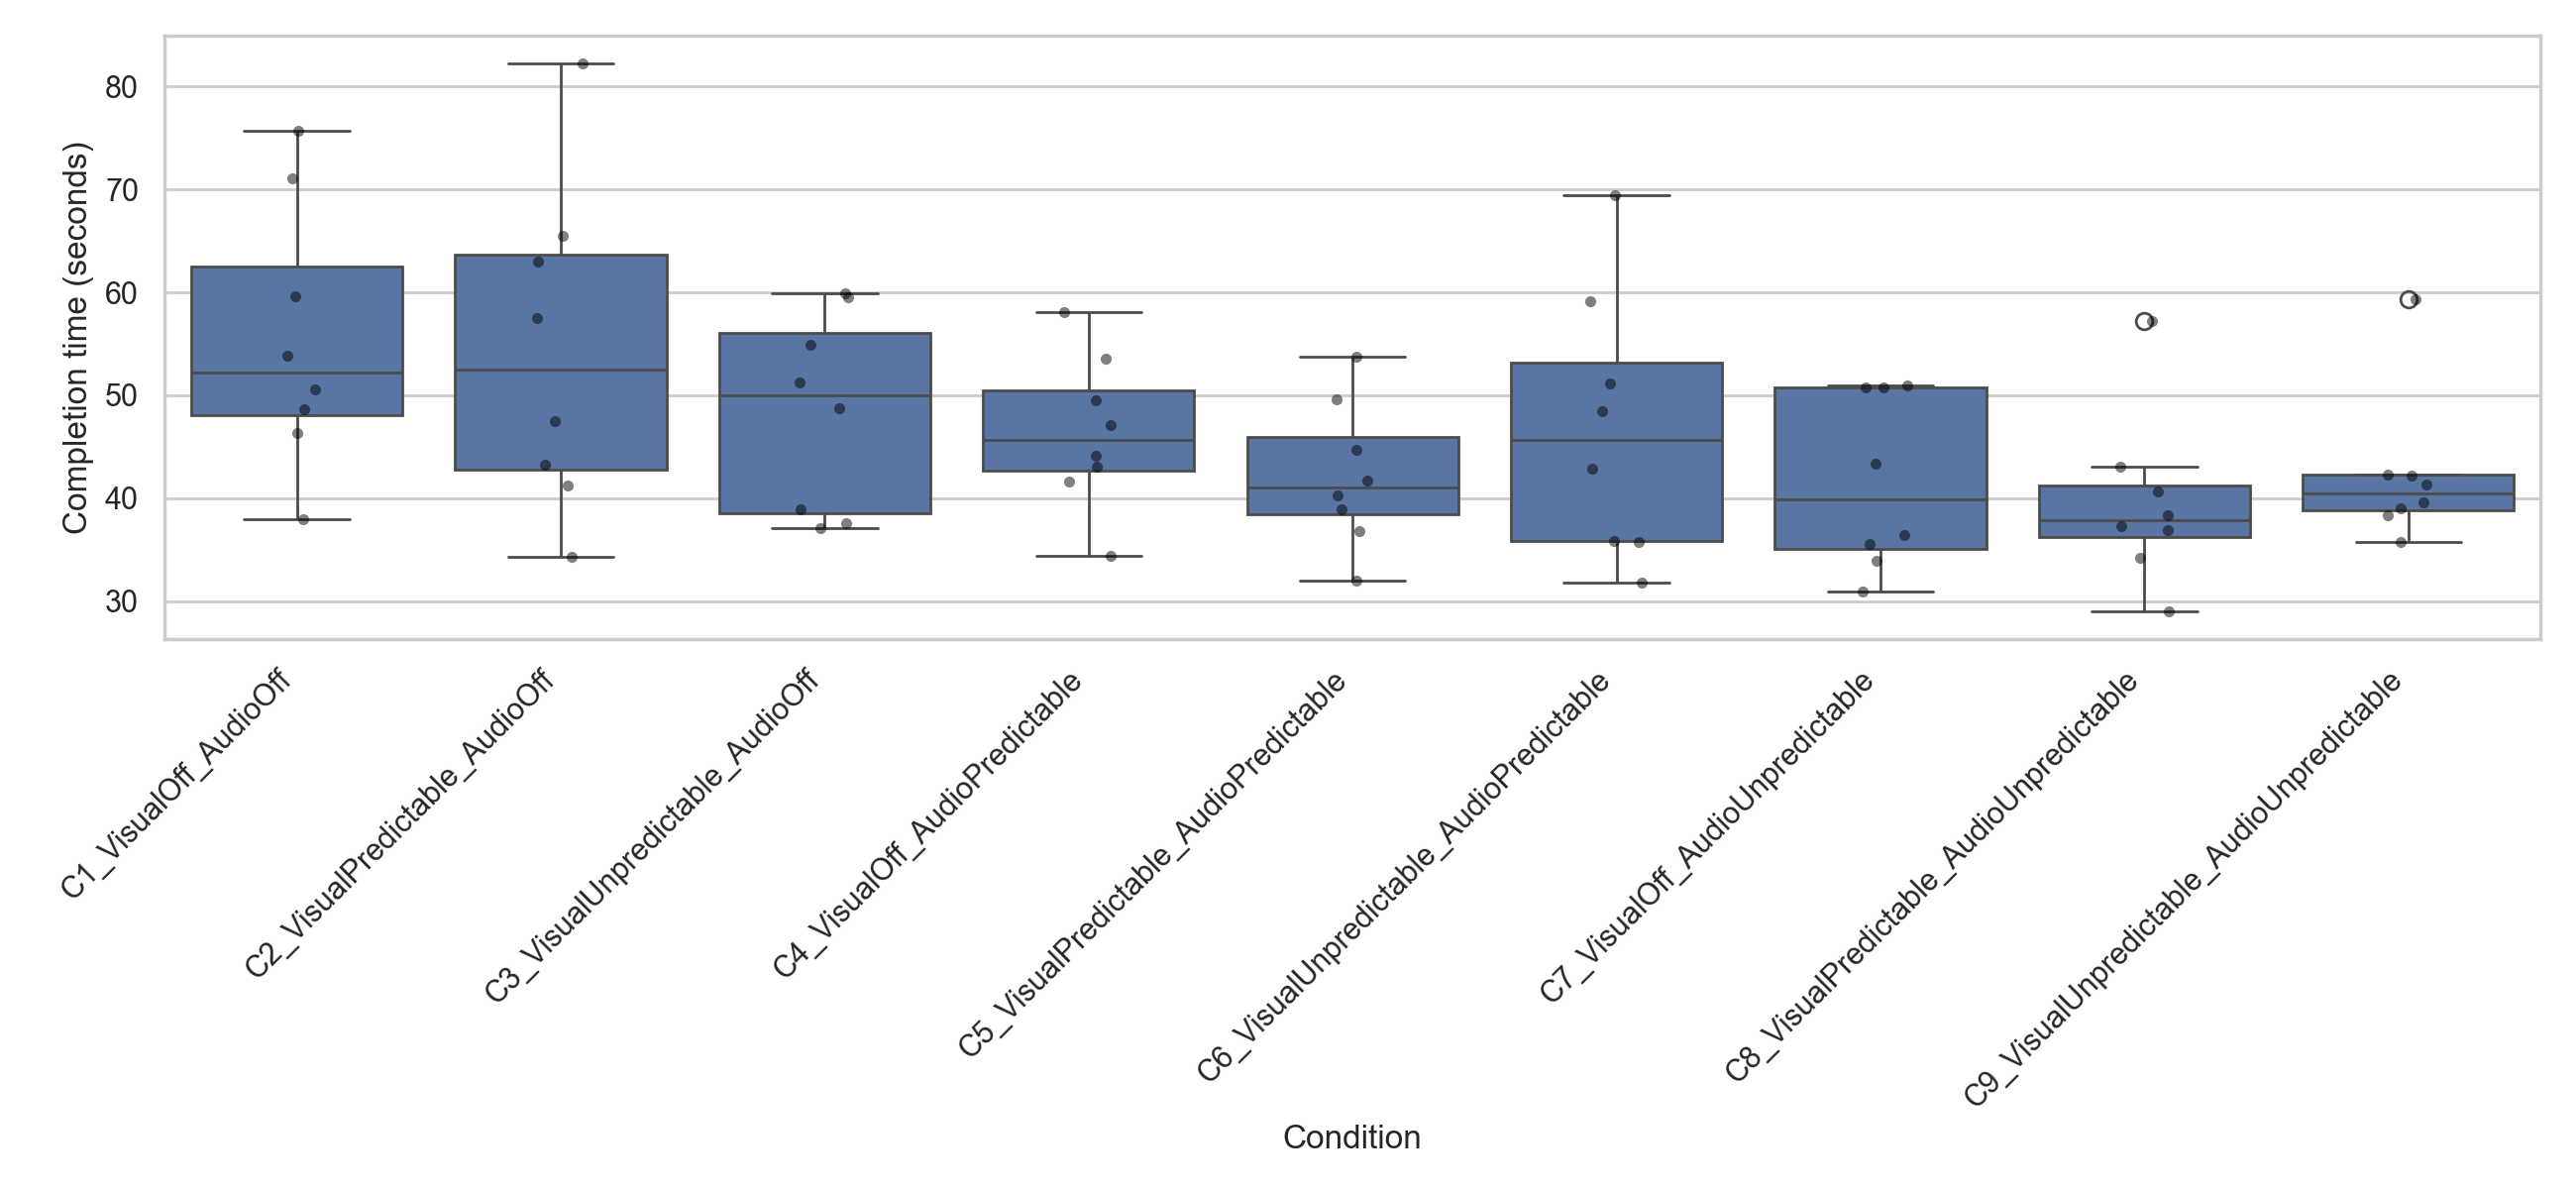

boxplot_mismatches_by_condition.png


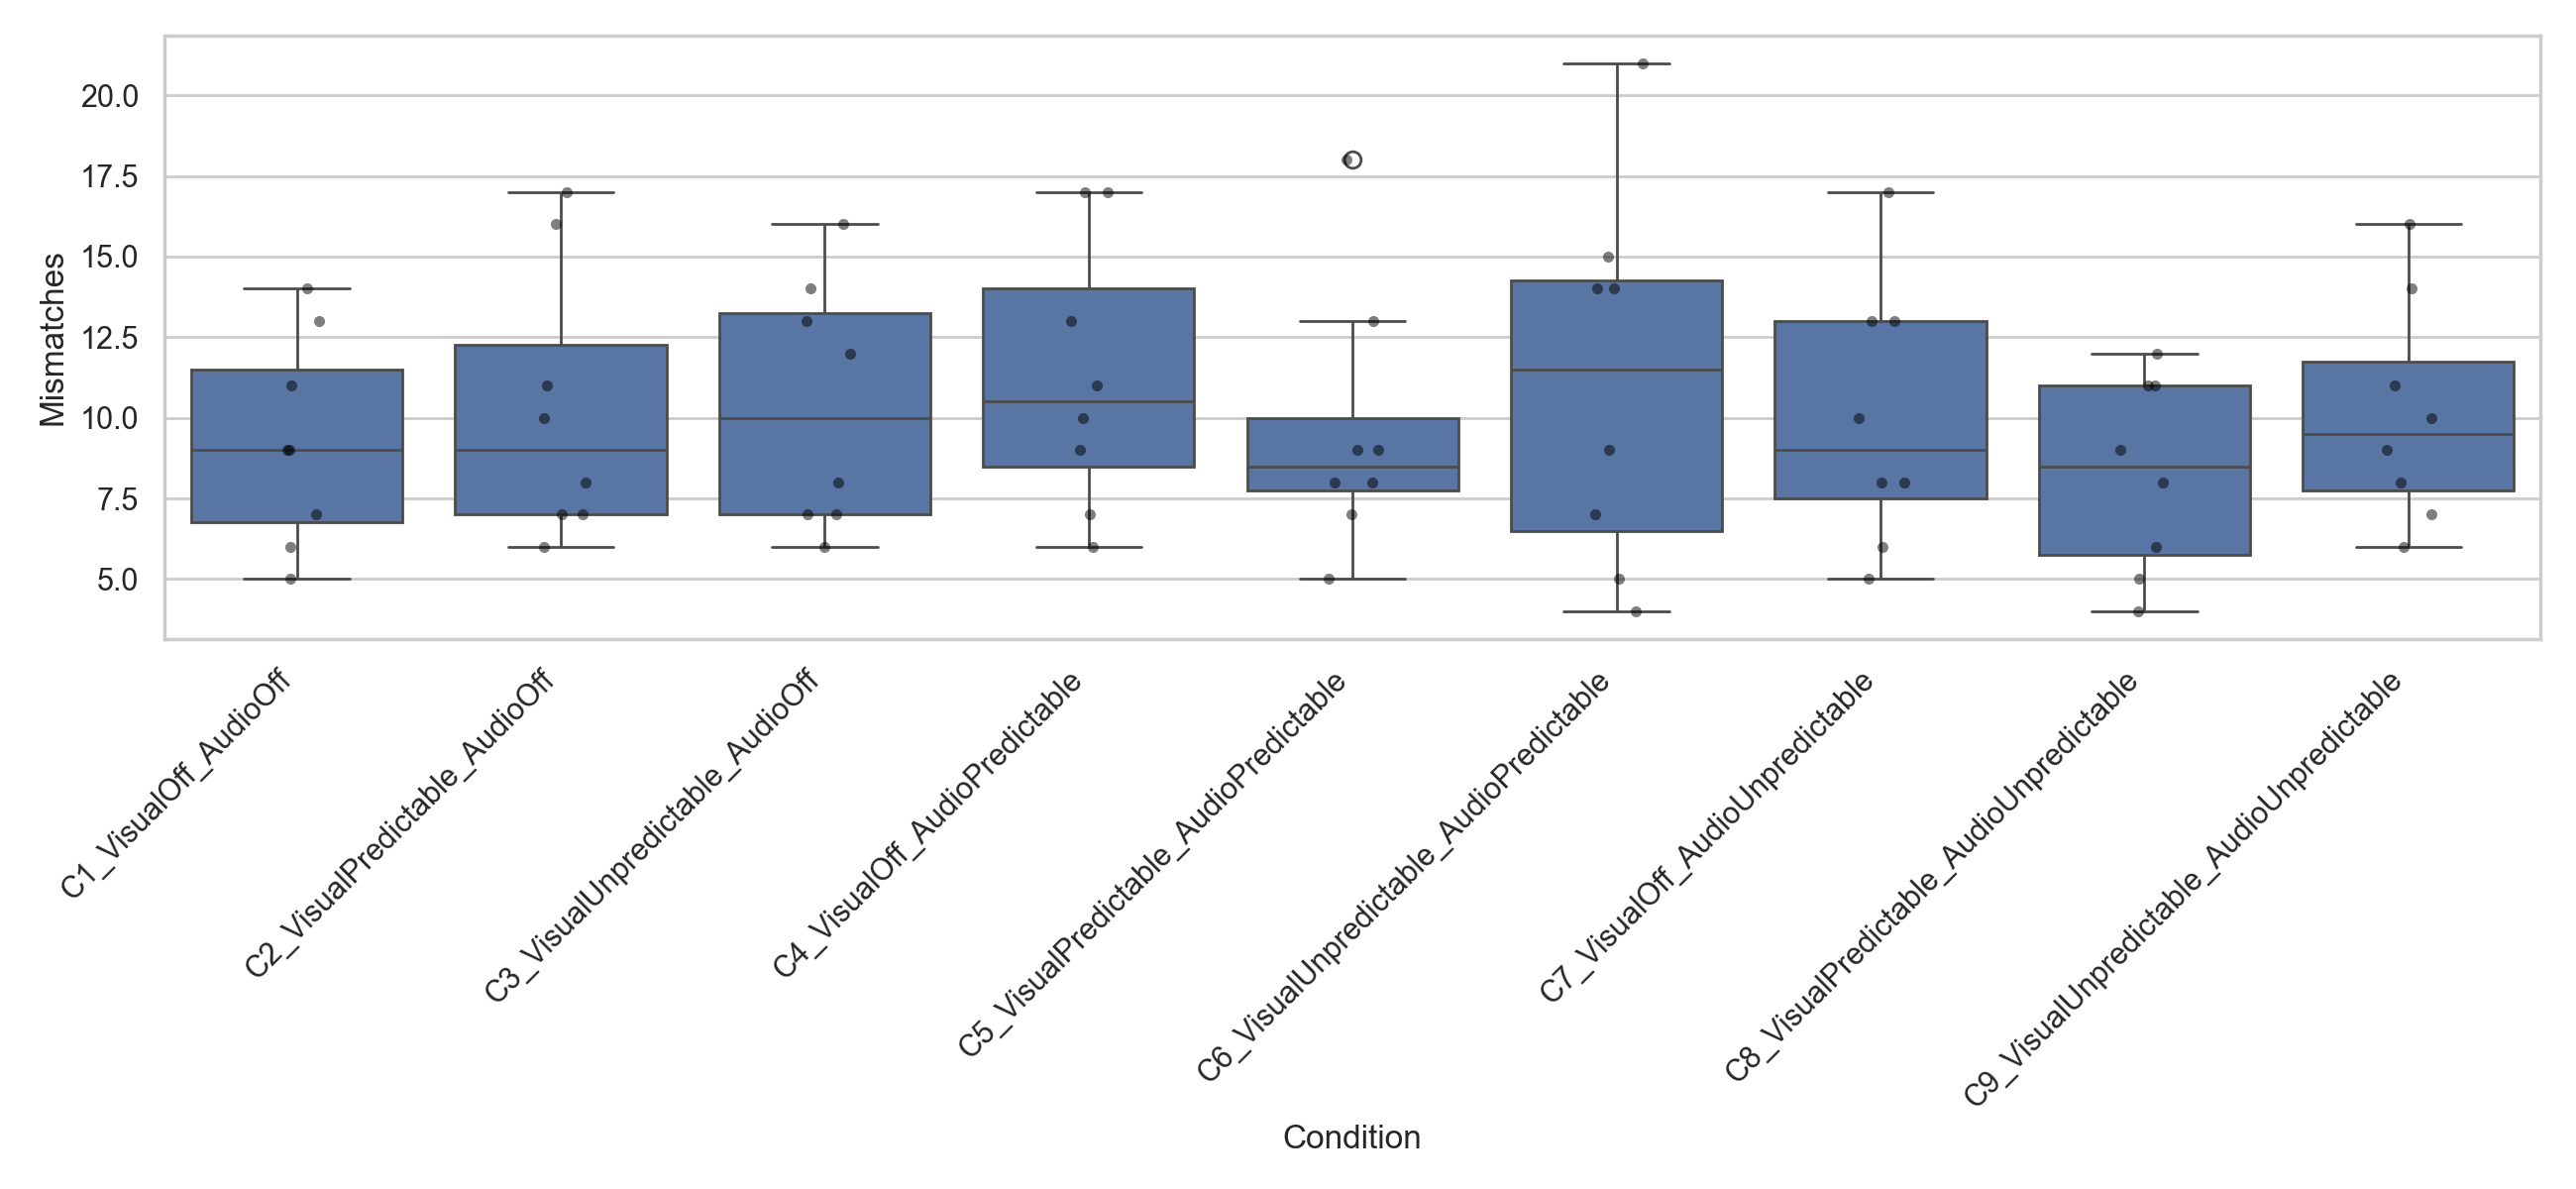

interaction_completion_time.png


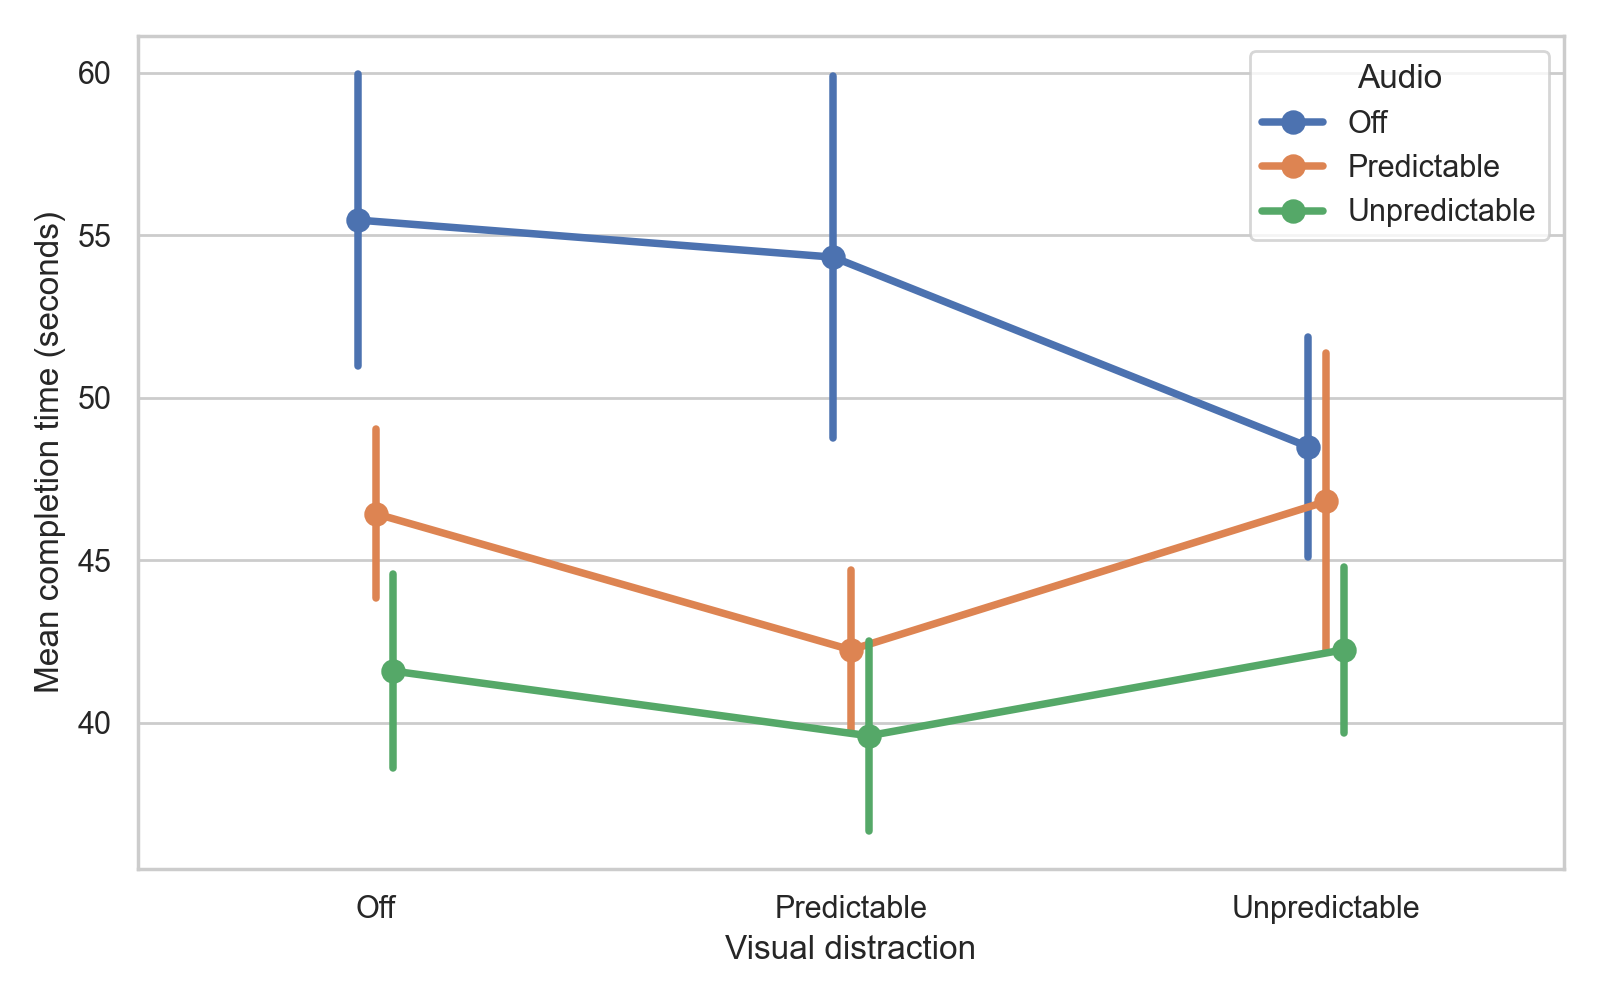

interaction_workload.png


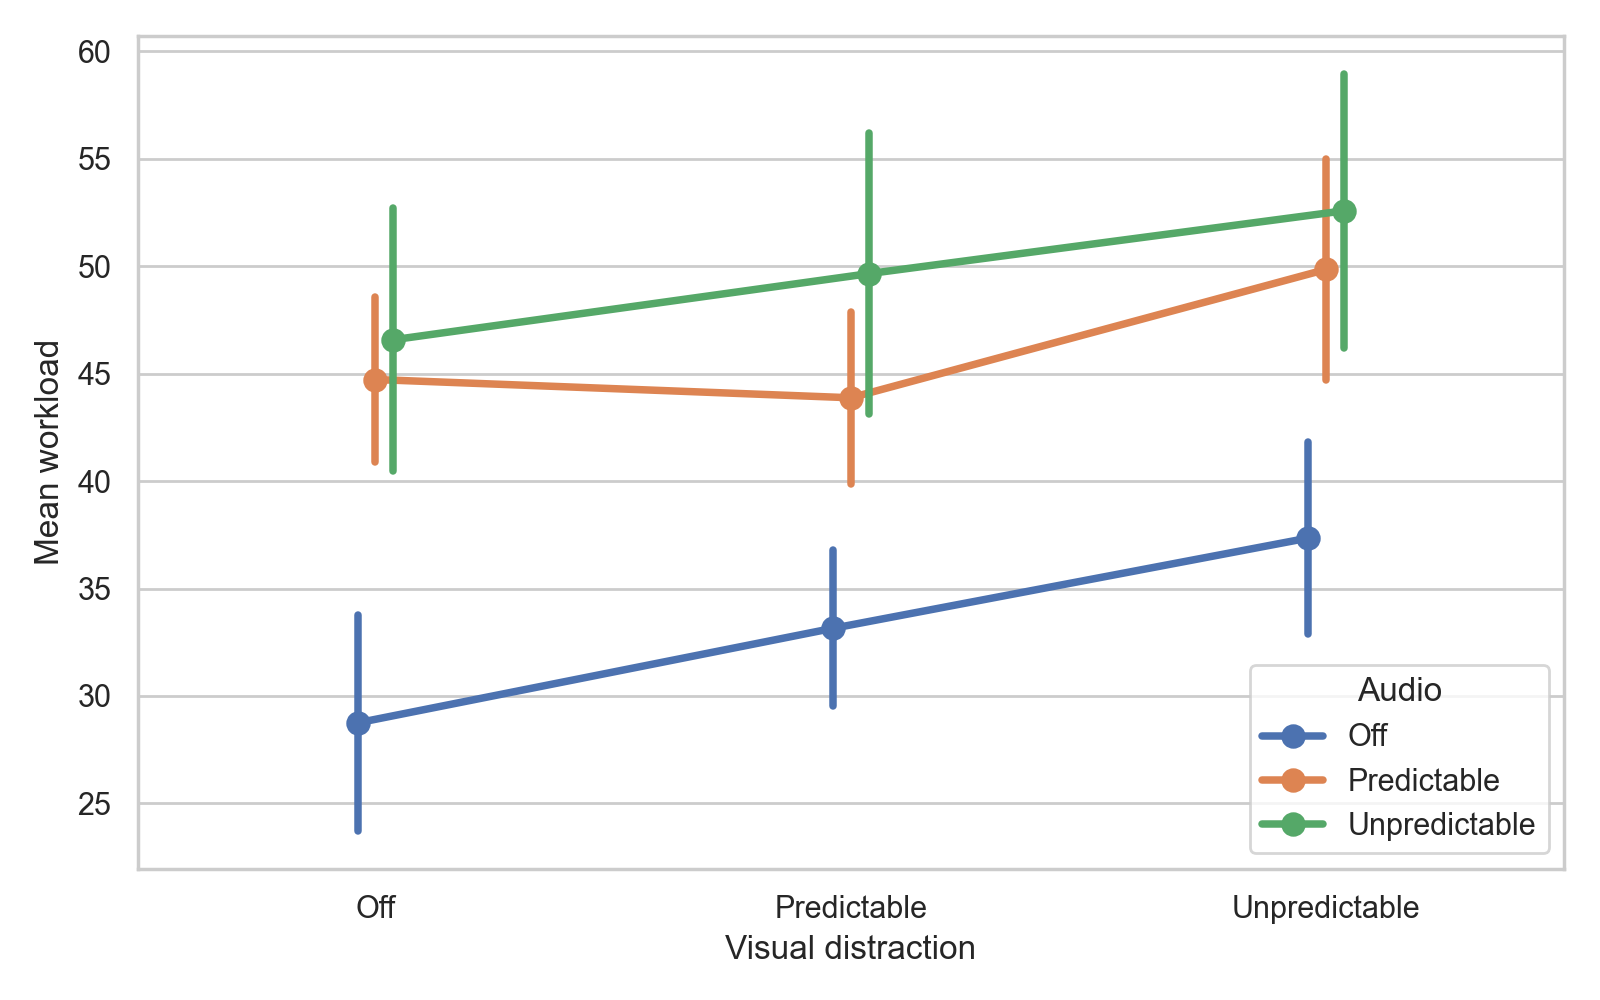

learning_effect_completion_time_by_round.png


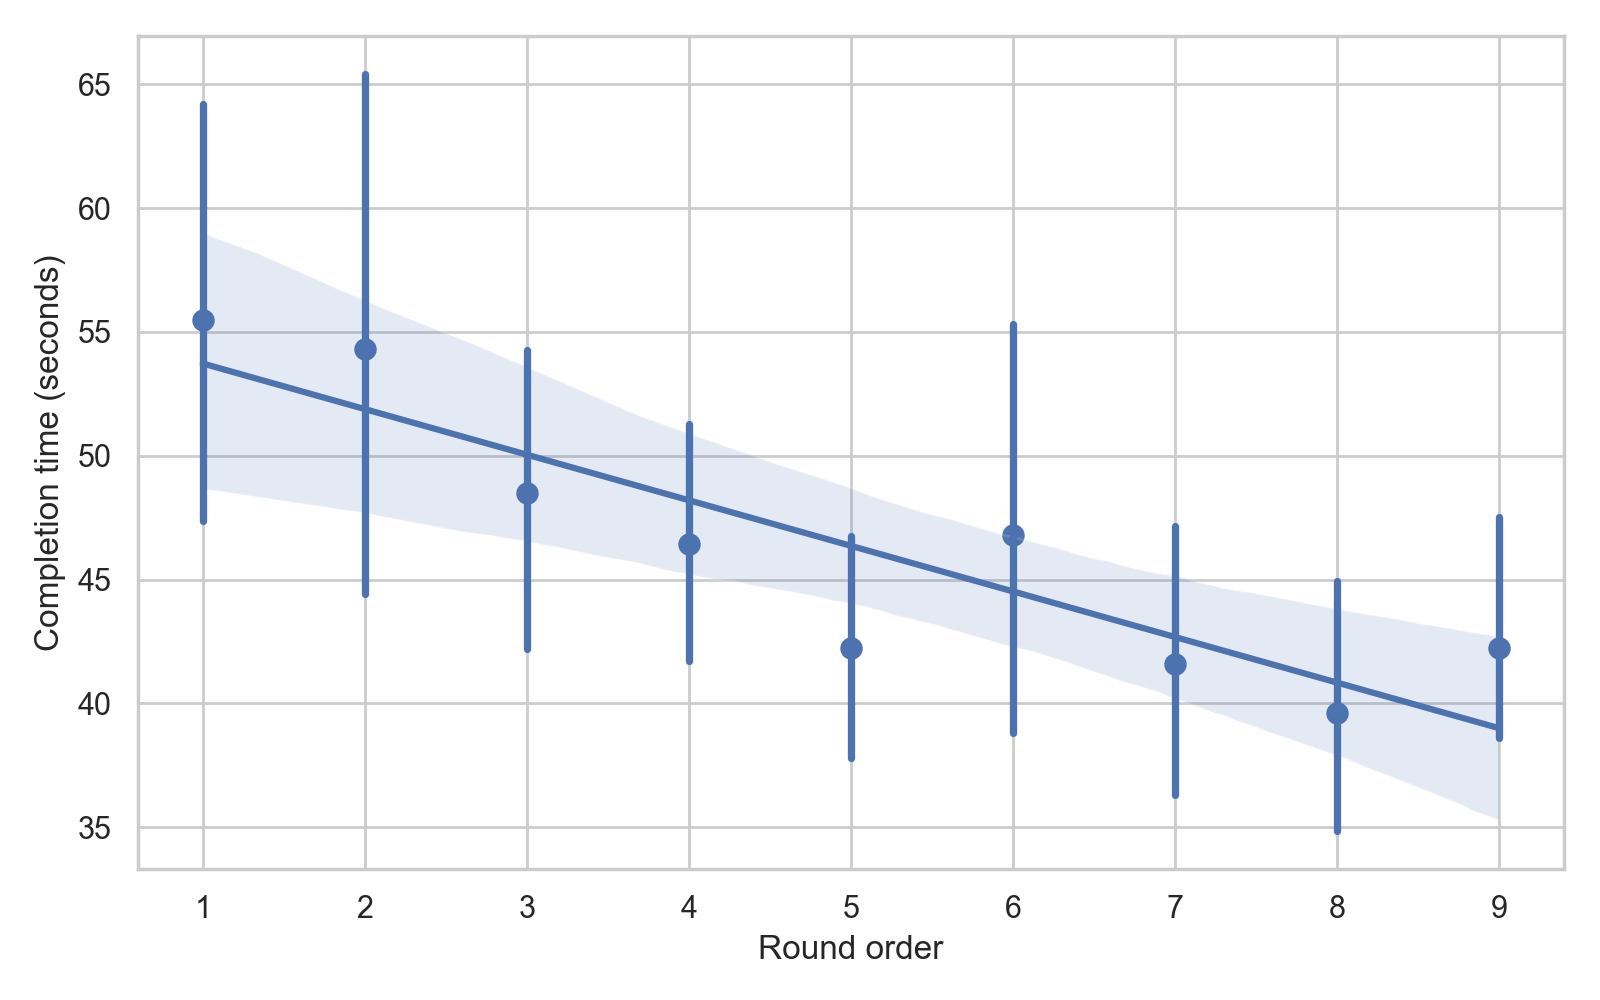

learning_effect_mismatches_by_round.png


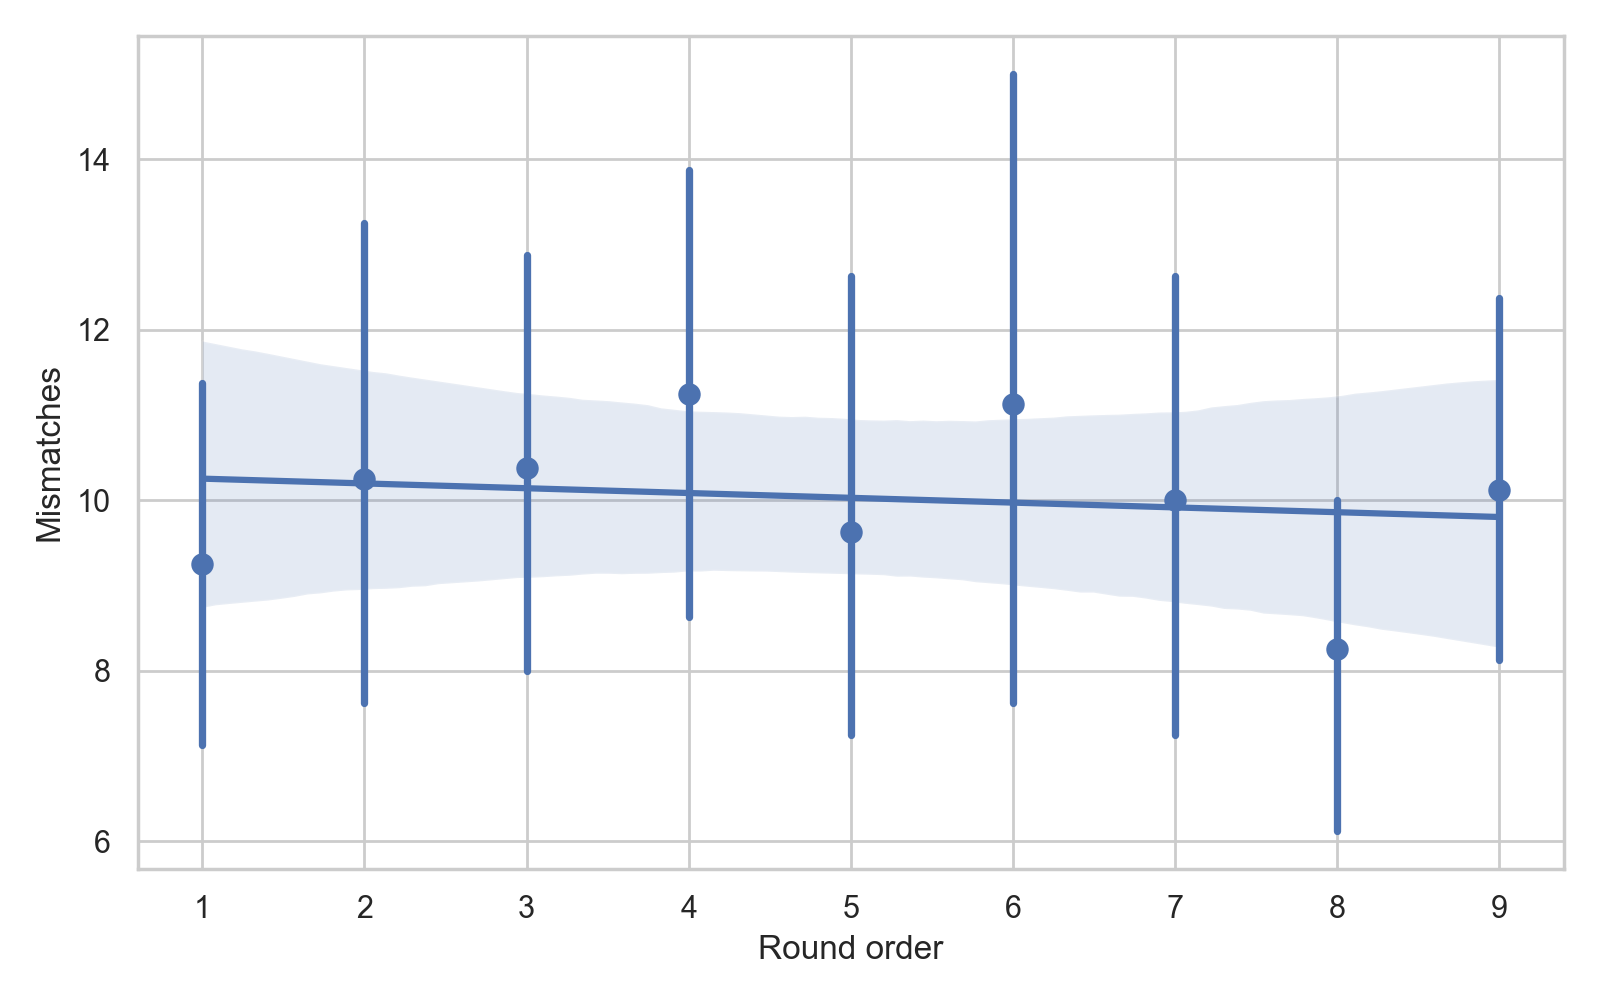

In [8]:
from IPython.display import Image, display
for img in [
    'boxplot_completion_time_by_condition.png',
    'boxplot_mismatches_by_condition.png',
    'interaction_completion_time.png',
    'interaction_workload.png',
    'learning_effect_completion_time_by_round.png',
    'learning_effect_mismatches_by_round.png',
]:
    print(img)
    display(Image(filename=str(OUTPUT_DIR / img)))